In [250]:
import pandas as pd

fake = pd.read_csv(r"D:\fake_news\Fake.csv")
true = pd.read_csv(r"D:\fake_news\True.csv")

display(fake.head(5))
display(true.head(5))

fake.info()
print(fake['subject'].value_counts())
display(fake.describe())

print("---------TRUE---------")
true.info()
print(true['subject'].value_counts())
true.describe()

print("valori lipsa in setul cu fake news: ", fake.isnull().sum())
print("valori lipsa in setul cu true news: ", true.isnull().sum())

print(fake.shape)
true.shape

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 733.9 KB
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64


,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


---------TRUE---------
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 669.4 KB
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64
valori lipsa in setul cu fake news:  title      0
text       0
subject    0
date       0
dtype: int64
valori lipsa in setul cu true news:  title      0
text       0
subject    0
date       0
dtype: int64
(23481, 4)


(21417, 4)

In [320]:
# 1. Adaugam label
fake['label'] = 1
true['label'] = 0

# 2. Combinam dataseturile
data = pd.concat([fake, true], ignore_index=True)
print(f"Shape dupa combinare: {data.shape}")
display(data.head(5))
print(f"Distributia claselor:\n{data['label'].value_counts()}")

display(data.describe())

# Toate randurile duplicate
duplicate_rows = data[data.duplicated(subset=['text'], keep=False)]
print(f"Total randuri duplicate: {len(duplicate_rows)}")
print(duplicate_rows.head(10))

# Punctul 2 - texte cu etichete contradictorii
duplicates = data[data.duplicated(subset=['text'], keep=False)]
contradictory = duplicates.groupby('text')['label'].nunique()
print("contradictory: ", contradictory)
contradictory = contradictory[contradictory > 1]
print(f"Texte cu etichete contradictorii: {len(contradictory)}")

# Punctul 3 - distributia duplicatelor
text_counts = data['text'].value_counts()
print("\nTop 10 texte cel mai des duplicate:")
print(text_counts[text_counts > 1].head(10))


# 3. Eliminam duplicate
data = data.drop_duplicates(subset=['text'])
print(f"Shape dupa eliminarea duplicatelor: {data.shape}")

print(data['label'].value_counts())
display(data.describe(include='object'))

# 4. Eliminam coloana subject si date 
# (subject - data leakage, date - irelevanta pentru continutul textului)
data = data[['text', 'label']]
print(f"Coloane ramase: {data.columns.tolist()}")
print(data.shape)

# 5. Shuffle
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Primele 5 randuri dupa shuffle:\n{data.head()}")

# print(data.nunique())

Shape dupa combinare: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


Distributia claselor:
label
1    23481
0    21417
Name: count, dtype: int64


,label
count,44898.000000
mean,0.522985
std,0.499477
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


Total randuri duplicate: 11392
                                                  title  \
9087  BARBRA STREISAND Gives Up On Dream Of Impeachi...   
9088  WATCH: SENATOR LINDSEY GRAHAM DROPS BOMBSHELL…...   
9089  “CONSERVATIVE GAY GUY” BLASTS Pence’s Aspen Ne...   
9091  BILL NYE The FAKE Science Guy THREATENS Conser...   
9093  EMBARRASSING: Anti-Trump “THE HILL” Gets SLAMM...   
9095  IT ONLY TOOK ONE TWEET FROM PRESIDENT TRUMP Fo...   
9096  WATCH HERO Singlehandedly Shut Down Anti-Trump...   
9097  FINALLY RELEASED! Email from Huma Abedin Inclu...   
9106  CNN’S FAKE NEWS BACKFIRES! CNN Legal Analyst A...   
9107  WHY THIS Democrat Stronghold County Voted For ...   

                                                   text   subject  \
9087  Barbra Streisand was an Obama sycophant and on...  politics   
9088  Everyone suspected the sketchy Steele Dossier ...  politics   
9089  It s been said that good fences make good neig...  politics   
9091  Friday on MSNBC, climate activist Bil

C:\Users\uie45446\AppData\Local\Temp\ipykernel_28232\1652846295.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(data.describe(include='object'))


,title,text,subject,date
count,38646,38646,38646,38646
unique,38270,38646,7,2397
top,Factbox: Trump fills top jobs for his administ...,Donald Trump just couldn t wish all Americans ...,politicsNews,"December 6, 2017"
freq,14,1,11213,166


Coloane ramase: ['text', 'label']
(38646, 2)
Primele 5 randuri dupa shuffle:
                                                text  label
0   (This September 29 has been corrected to fix ...      0
1  WASHINGTON/CAIRO (Reuters) - Five Iraqi passen...      0
2  PRISTINA (Reuters) - Kosovo s center-right coa...      0
3  WASHINGTON (Reuters) - President Donald Trump ...      0
4  A Pennsylvania man apparently failed basic bio...      1


In [322]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline

# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'],
    test_size=0.2,
    random_state=42,
    stratify=data['label']
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distributie train:\n{y_train.value_counts(normalize=True)}")
print(f"Distributie train:\n{y_test.value_counts(normalize=True)}")

# 2. Pipeline Logistic Regression
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=50000)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# 3. Pipeline Random Forest
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=50000)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 4. Antrenare
print("\nAntrenare Logistic Regression...")
pipeline_lr.fit(X_train, y_train)

print("Antrenare Random Forest...")
pipeline_rf.fit(X_train, y_train)

# 5. Evaluare
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print("\n=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")

Train: (30916,), Test: (7730,)
Distributie train:
label
0    0.548324
1    0.451676
Name: proportion, dtype: float64
Distributie train:
label
0    0.548383
1    0.451617
Name: proportion, dtype: float64

Antrenare Logistic Regression...
Antrenare Random Forest...

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4239
           1       0.98      0.98      0.98      3491

    accuracy                           0.98      7730
   macro avg       0.98      0.98      0.98      7730
weighted avg       0.98      0.98      0.98      7730

AUC-ROC: 0.998

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4239
           1       0.99      0.98      0.99      3491

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730

AUC-ROC: 0.999


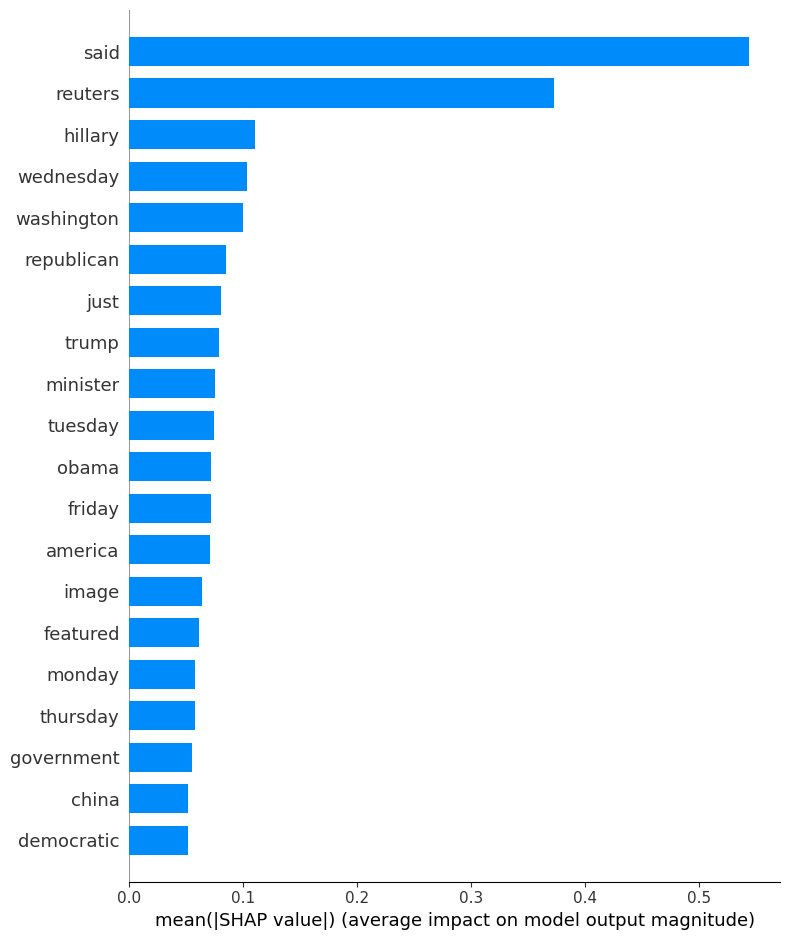

In [324]:
# Folosim pipeline_lr in loc de pipeline_rf
tfidf = pipeline_lr.named_steps['tfidf']
lr = pipeline_lr.named_steps['model']

X_sample = tfidf.transform(X_test.iloc[:100]).toarray()

explainer = shap.LinearExplainer(lr, X_sample)
shap_values = explainer.shap_values(X_sample)

# Plot
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=tfidf.get_feature_names_out(),
    max_display=20,
    plot_type="bar"
)

In [325]:
import re

def clean_text(text):
    text = re.sub(r'\(Reuters\)', '', text)
    text = re.sub(r'WASHINGTON|NEW YORK|LONDON', '', text)
    # Elimina zile si luni
    text = re.sub(r'\b(Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)\b', '', text, flags=re.IGNORECASE)
    return text.strip()

data['text_clean'] = data['text'].apply(clean_text)

print(data.columns.to_list())
data = data.drop('text', axis=1)
print(data.columns.to_list())

['text', 'label', 'text_clean']
['label', 'text_clean']


In [326]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    data['text_clean'], data['label'],
    test_size=0.2,
    random_state=42,
    stratify=data['label']
)

print(X_train_clean.shape)
print(X_test_clean.shape)
print(y_train_clean.shape)
print(y_test_clean.shape)

print((y_train_clean == 1).value_counts(normalize=True))
print((y_test_clean == 1).value_counts(normalize=True))

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=50000)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=50000)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_lr.fit(X_train_clean, y_train_clean)
pipeline_rf.fit(X_train_clean, y_train_clean)

y_pred_lr = pipeline_lr.predict(X_test_clean)
y_prob_lr = pipeline_lr.predict_proba(X_test_clean)[:, 1]
y_pred_rf = pipeline_rf.predict(X_test_clean)
y_prob_rf = pipeline_rf.predict_proba(X_test_clean)[:, 1]



print(classification_report(y_test_clean, y_pred_lr))
print(f"ROC-AUC e: {roc_auc_score(y_test_clean, y_prob_lr)}")

print(classification_report(y_test_clean, y_pred_rf))
print(f"ROC-AUC e: {roc_auc_score(y_test_clean, y_prob_rf)}")

(30916,)
(7730,)
(30916,)
(7730,)
label
False    0.548324
True     0.451676
Name: proportion, dtype: float64
label
False    0.548383
True     0.451617
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4239
           1       0.98      0.97      0.97      3491

    accuracy                           0.97      7730
   macro avg       0.97      0.97      0.97      7730
weighted avg       0.97      0.97      0.97      7730

ROC-AUC e: 0.9959851602364561
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      4239
           1       0.98      0.95      0.96      3491

    accuracy                           0.97      7730
   macro avg       0.97      0.97      0.97      7730
weighted avg       0.97      0.97      0.97      7730

ROC-AUC e: 0.9955320015766623


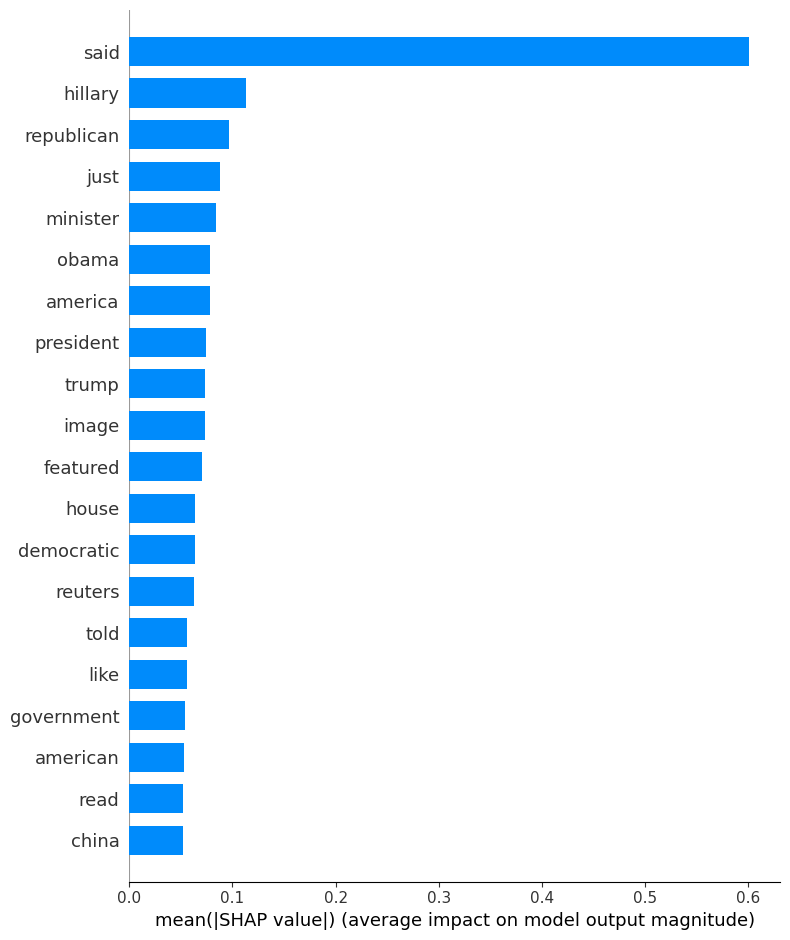

In [327]:

tfidf = pipeline_lr.named_steps['tfidf']
lr = pipeline_lr.named_steps['model']

X_sample = tfidf.transform(X_test_clean.iloc[:100]).toarray()

explainer = shap.LinearExplainer(lr, X_sample)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=tfidf.get_feature_names_out(),
    max_display=20,
    plot_type="bar"
)

Prima stire fake la pozitia: 0

Textul articolului:
Rep. Louie Gohmert is perhaps America s most troubled congressperson. Vehemently anti-gay, the Representative from Texas has often made headlines for his nonsensical speeches. All of them were put to shame when Gohmert walked up to the podium on May 26 and began speaking about asteroids, Matt Damon ...


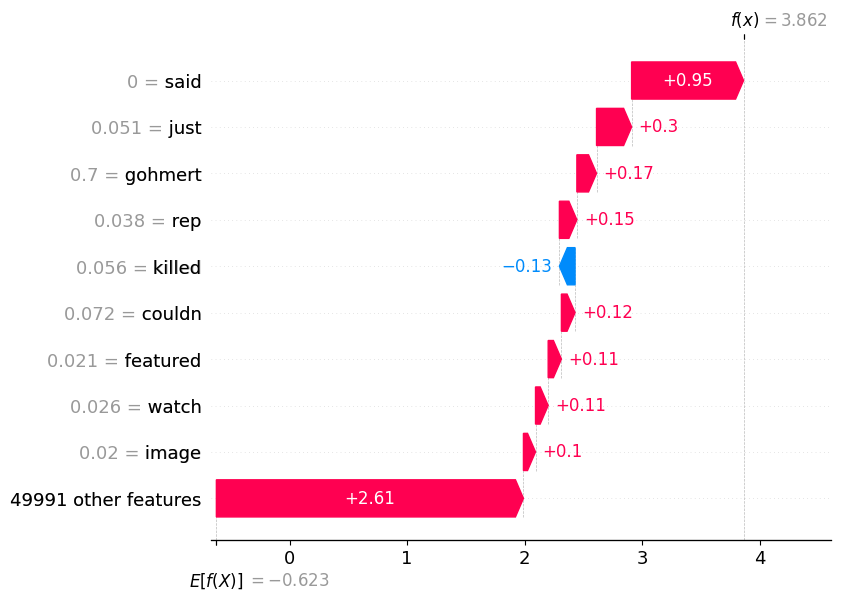

In [328]:
import shap
import numpy as np

tfidf = pipeline_lr.named_steps['tfidf']
lr = pipeline_lr.named_steps['model']

X_test_tfidf = tfidf.transform(X_test_clean).toarray()

y_test_reset = y_test_clean.reset_index(drop=True)

fake_positions = y_test_reset[y_test_reset == 1].index.tolist()
fake_pos = fake_positions[0]
print(f"Prima stire fake la pozitia: {fake_pos}")
print(f"\nTextul articolului:\n{X_test_clean.iloc[fake_pos][:300]}...")

explainer = shap.LinearExplainer(lr, X_test_tfidf)
shap_values = explainer.shap_values(X_test_tfidf)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fake_pos],
        base_values=explainer.expected_value,
        data=X_test_tfidf[fake_pos],
        feature_names=tfidf.get_feature_names_out()
    )
)